In [74]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
from matplotlib.lines import Line2D
from matplotlib.legend import Legend

Line2D._us_dashSeq = property(lambda self: self._dash_pattern[1])
Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])
Legend._ncol = property(lambda self: self._ncols)

plot_scale = 0.5

In [76]:
from utils.datasets.base_dataset import QUERY_TYPE
from pathlib import Path
import pandas as pd
from utils.helpers import (
    to_pow_10,
    pretty_print_counts,
    collapse_first_rows,
    to_multicol,
    add_args,
    darken_color
)


In [77]:
results_dir = Path("scratch") / "results"
figures_dir = Path("scratch") / "figures"

tables_dir = figures_dir / "tables"
macro_dir = figures_dir / "macros"
figures_dir.mkdir(exist_ok=True, parents=True)


def combine_dfs(pattern: str, base_dir: Path) -> pd.DataFrame:
    dfs = []
    for file in base_dir.glob(pattern):
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


modes = {
    "bsbm": "BSBM-DVQ",
    "dbpedia": "DBpedia-MS",
}
mode = "bsbm"
table_dir = figures_dir / "tables" / mode
table_dir.mkdir(parents=True, exist_ok=True)
# stats_df = combine_dfs(f"{mode}_stats*.csv", results_dir)
# timings_df = combine_dfs(f"{mode}_timings*.csv", results_dir)
timings_df = pd.read_csv(results_dir / mode / f"{mode}_timings_all.csv")
stats_df = pd.read_csv(results_dir / mode / f"{mode}_stats_all.csv")
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-09-03 12:10:28.675017,0.0,69525504,-1,-1,2,2418,3,easy,embedded,1,QLever
1,2026-09-03 12:10:28.691577,0.0,69689344,-1,-1,2,2418,3,easy,embedded,1,QLever
2,2026-09-03 12:10:28.817383,0.0,77717504,-1,-1,2,2418,3,easy,embedded,1,QLever
3,2026-09-03 12:10:28.946809,0.0,77705216,-1,-1,2,2418,3,easy,embedded,1,QLever
4,2026-09-03 12:10:29.066173,0.0,77705216,-1,-1,2,2418,3,easy,embedded,1,QLever
...,...,...,...,...,...,...,...,...,...,...,...,...
109408,2026-09-03 16:19:00.270476,0.0,754675712,-1,-1,2,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor
109409,2026-09-03 16:19:01.670383,0.0,754675712,-1,-1,2,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor
109410,2026-09-03 16:19:01.945003,0.0,754675712,-1,-1,2,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor
109411,2026-09-03 16:19:02.201436,0.0,754675712,-1,-1,2,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor


In [78]:
from utils.format import map_df_readable


stats_df = map_df_readable(stats_df)
timings_df = map_df_readable(timings_df)
timings_df

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
0,2418,3,1,0,\systemname-TV,Scan,Embedded,0.004163,0.000000,1.0,0.01
1,2418,3,1,1,\systemname-TV,Scan,Embedded,0.003498,0.000000,1.0,0.00
2,2418,3,1,2,\systemname-TV,Scan,Embedded,0.002492,0.000000,1.0,0.00
3,2418,3,1,3,\systemname-TV,Scan,Embedded,0.002998,0.000000,1.0,0.00
4,2418,3,1,4,\systemname-TV,Scan,Embedded,0.002329,0.000000,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
8485,35177974,7,100000,125,RDFTensor,Scan,Two Stage,13.865492,0.804247,0.1,9.94
8486,35177974,7,100000,126,RDFTensor,Scan,Two Stage,13.879721,0.804247,0.1,9.94
8487,35177974,7,100000,127,RDFTensor,Scan,Two Stage,14.090839,0.804247,0.1,9.91
8488,35177974,7,100000,0,RDFTensor,Join,Embedded,inf,-1.000000,-1.0,NaN


In [79]:
timings_df[(timings_df["query_type"] == "index") & (timings_df["engine"] == "QLever (TV)") & (timings_df["difficulty"] == "hard")].sort_values("size")

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time


In [80]:
import numpy as np
timings_df = timings_df[timings_df["elapsed_time"].replace([np.inf, -np.inf], np.nan).notna()]

In [81]:
hard_timings = timings_df[timings_df["difficulty"] == "hard"]
hard_timings

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time


In [82]:
# timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['\systemname-TV', '\systemname-Base', 'Neo4j', 'RDFTensor']
Length: 4, dtype: str

In [83]:
engines = timings_df["engine"].sort_values().unique()
difficulties = timings_df["difficulty"].unique()
query_types = timings_df["query_type"].unique()
engines, difficulties, query_types

(<ArrowStringArray>
 ['Neo4j', 'RDFTensor', '\systemname-Base', '\systemname-TV']
 Length: 4, dtype: str,
 <ArrowStringArray>
 ['Scan', 'Join']
 Length: 2, dtype: str,
 <ArrowStringArray>
 ['Embedded', 'Index', 'Two Stage']
 Length: 3, dtype: str)

In [84]:
timings_df

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
0,2418,3,1,0,\systemname-TV,Scan,Embedded,0.004163,0.000000,1.0,0.01
1,2418,3,1,1,\systemname-TV,Scan,Embedded,0.003498,0.000000,1.0,0.00
2,2418,3,1,2,\systemname-TV,Scan,Embedded,0.002492,0.000000,1.0,0.00
3,2418,3,1,3,\systemname-TV,Scan,Embedded,0.002998,0.000000,1.0,0.00
4,2418,3,1,4,\systemname-TV,Scan,Embedded,0.002329,0.000000,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
8483,35177974,7,100000,123,RDFTensor,Scan,Two Stage,13.853915,0.804247,0.1,9.81
8484,35177974,7,100000,124,RDFTensor,Scan,Two Stage,13.976239,0.804247,0.1,10.00
8485,35177974,7,100000,125,RDFTensor,Scan,Two Stage,13.865492,0.804247,0.1,9.94
8486,35177974,7,100000,126,RDFTensor,Scan,Two Stage,13.879721,0.804247,0.1,9.94


In [85]:
engines = list(timings_df["engine"].unique())
engines.sort()
baseline_engine = engines[0 if mode == "dbpedia" else 1]
engines, baseline_engine

(['Neo4j', 'RDFTensor', '\\systemname-Base', '\\systemname-TV'], 'RDFTensor')

In [86]:
timings_df

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
0,2418,3,1,0,\systemname-TV,Scan,Embedded,0.004163,0.000000,1.0,0.01
1,2418,3,1,1,\systemname-TV,Scan,Embedded,0.003498,0.000000,1.0,0.00
2,2418,3,1,2,\systemname-TV,Scan,Embedded,0.002492,0.000000,1.0,0.00
3,2418,3,1,3,\systemname-TV,Scan,Embedded,0.002998,0.000000,1.0,0.00
4,2418,3,1,4,\systemname-TV,Scan,Embedded,0.002329,0.000000,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
8483,35177974,7,100000,123,RDFTensor,Scan,Two Stage,13.853915,0.804247,0.1,9.81
8484,35177974,7,100000,124,RDFTensor,Scan,Two Stage,13.976239,0.804247,0.1,10.00
8485,35177974,7,100000,125,RDFTensor,Scan,Two Stage,13.865492,0.804247,0.1,9.94
8486,35177974,7,100000,126,RDFTensor,Scan,Two Stage,13.879721,0.804247,0.1,9.94


In [87]:
timings_df.groupby(
    ["difficulty", "estimated_size", "query_type", "engine", "size"]
).count()

power  rep  \
difficulty estimated_size query_type engine           size                   
Join       1              Embedded   Neo4j            2418        128  128   
                                     RDFTensor        2418        128  128   
                                     \systemname-Base 2418        128  128   
                                     \systemname-TV   2418        128  128   
                          Index      \systemname-Base 2418        128  128   
...                                                               ...  ...   
Scan       100000         Embedded   \systemname-Base 35177974    127  127   
                                     \systemname-TV   35177974    128  128   
                          Index      \systemname-Base 35177974    128  128   
                                     \systemname-TV   35177974    128  128   
                          Two Stage  RDFTensor        35177974    127  127   

                                                                elapsed_time  \
difficulty estimated_size query_type engine           size                     
Join       1              Embedded   Neo4j            2418               128   
                                     RDFTensor        2418               128   
                                     \systemname-Base 2418               128   
                                     \systemname-TV   2418               128   
                          Index      \systemname-Base 2418               128   
...                                                                      ...   
Scan       100000         Embedded   \systemname-Base 35177974           127   
                                     \systemname-TV   35177974           128   
                          Index      \systemname-Base 35177974           128   
                                     \systemname-TV   35177974           128   
                          Two Stage  RDFTensor        35177974           127   

                                                                ndcg_score  \
difficulty estimated_size query_type engine           size                   
Join       1              Embedded   Neo4j            2418             128   
                                     RDFTensor        2418             128   
                                     \systemname-Base 2418             128   
                                     \systemname-TV   2418             128   
                          Index      \systemname-Base 2418             128   
...                                                                    ...   
Scan       100000         Embedded   \systemname-Base 35177974         127   
                                     \systemname-TV   35177974         128   
                          Index      \systemname-Base 35177974         128   
                                     \systemname-TV   35177974         128   
                          Two Stage  RDFTensor        35177974         127   

                                                                recall_score  \
difficulty estimated_size query_type engine           size                     
Join       1              Embedded   Neo4j            2418               128   
                                     RDFTensor        2418               128   
                                     \systemname-Base 2418               128   
                                     \systemname-TV   2418               128   
                          Index      \systemname-Base 2418               128   
...                                                                      ...   
Scan       100000         Embedded   \systemname-Base 35177974           127   
                                     \systemname-TV   35177974           128   
                          Index      \systemname-Base 35177974           128   
                                     \systemname-TV   35177974           128   
                          Two Sta

In [88]:
timings_df[["difficulty", "size", "query_type", "engine"]]

,difficulty,size,query_type,engine
0,Scan,2418,Embedded,\systemname-TV
1,Scan,2418,Embedded,\systemname-TV
2,Scan,2418,Embedded,\systemname-TV
3,Scan,2418,Embedded,\systemname-TV
4,Scan,2418,Embedded,\systemname-TV
...,...,...,...,...
8483,Scan,35177974,Two Stage,RDFTensor
8484,Scan,35177974,Two Stage,RDFTensor
8485,Scan,35177974,Two Stage,RDFTensor
8486,Scan,35177974,Two Stage,RDFTensor


In [89]:
stats_df[["difficulty", "size", "query_type", "engine"]].values

array([['Scan', 2418, 'Embedded', '\\systemname-TV'],
       ['Scan', 2418, 'Embedded', '\\systemname-TV'],
       ['Scan', 2418, 'Embedded', '\\systemname-TV'],
       ...,
       ['Join', 35177974, 'Two Stage', 'RDFTensor'],
       ['Join', 35177974, 'Two Stage', 'RDFTensor'],
       ['Join', 35177974, 'Two Stage', 'RDFTensor']],
      shape=(109413, 4), dtype=object)

In [90]:
stats_df_only_valid = stats_df[
    stats_df.set_index(["difficulty", "size", "query_type", "engine"]).index
    .isin(
        timings_df.set_index(["difficulty", "size", "query_type", "engine"]).index
    )
]
stats_df_only_valid.shape, stats_df.shape

((89691, 12), (109413, 12))

In [91]:
from scipy.stats import ttest_ind, ttest_1samp, median_test, gmean


def siginificance_level(p_value: float) -> str:
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


# calculate the mean speedup vs the baseline engine for each difficulty + query type + engine + size
# + whether the speedup is statistically significant (using a t-test)
# the baseline engine
def calculate_speedup(
    df: pd.DataFrame, baseline_engine: str, baseline_type: str, relevant_measure: str
) -> pd.DataFrame:
    results = []
    chunks = df.groupby(
        ["difficulty", "query_type", "engine", "estimated_size", "size"]
    )
    print(f"Calculating speedup for {len(chunks)} groups on df of shape {df.shape}")
    super_chunks = df.groupby(
        [
            "difficulty",
            "query_type",
            "engine",
        ]
    )
    for i, group in chunks:
        super_group = super_chunks.get_group(
            (
                group["difficulty"].iloc[0],
                group["query_type"].iloc[0],
                group["engine"].iloc[0],
            )
        )
        if group.empty:
            print(f"Skipping empty group: {group.index}")
            continue
        baseline_group = df[
            (df["difficulty"] == group["difficulty"].iloc[0])
            & (df["query_type"] == baseline_type)
            & (df["engine"] == baseline_engine)
            & (df["estimated_size"] == group["estimated_size"].iloc[0])
            & (df["size"] == group["size"].iloc[0])
        ]
        measure_group = group[relevant_measure]
        measure_baseline_group: pd.Series = baseline_group[relevant_measure]
        # vs baseline group using a t-test
        t_stat, p_value_baseline = ttest_ind(
            measure_group, measure_baseline_group, equal_var=False, alternative="less"
        )
        # vs first measure of the group (cold start) using a t-test
        cold_start_measure = measure_group.iloc[0]
        t_stat_cold, p_value_cold = ttest_1samp(
            measure_baseline_group,
            cold_start_measure,
            alternative="greater",
        )

        adjusted_alpha = 0.01 / len(chunks)  # Bonferroni correction
        speedup = measure_baseline_group.median() / measure_group.median()
        speedup_cold = measure_baseline_group.median() / cold_start_measure
        result = {
            "difficulty": group["difficulty"].iloc[0],
            "query_type": group["query_type"].iloc[0],
            "engine": group["engine"].iloc[0],
            "estimated_size": group["estimated_size"].iloc[0],
            "size": group["size"].iloc[0],
            "measure": gmean(measure_group),
            "speedup": speedup,
            "speedup_cold": speedup_cold,
            "p_value_baseline": p_value_baseline,
            "p_value_cold": p_value_cold,
            "significance_level": siginificance_level(p_value_baseline),
            "significant": p_value_baseline < adjusted_alpha,
            "siginificance_level_cold": siginificance_level(p_value_cold),
            "significant_cold": p_value_cold < adjusted_alpha,
        }
        if mode == "dbpedia":
            del result["estimated_size"]

        results.append(result)
    df = pd.DataFrame(results)
    # index by difficulty, query type, engine, size
    # df.set_index(["difficulty", "query_type", "engine", "size"], inplace=True)
    return df


speedup = calculate_speedup(timings_df, baseline_engine, "Embedded", "elapsed_time")
speedup

Calculating speedup for 66 groups on df of shape (8445, 11)


/tmp/ipykernel_726690/607422786.py:54: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value_baseline = ttest_ind(
/tmp/ipykernel_726690/607422786.py:59: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat_cold, p_value_cold = ttest_1samp(
/tmp/ipykernel_726690/607422786.py:54: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value_baseline = ttest_ind(
/tmp/ipykernel_726690/607422786.py:59: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat_cold, p_value_cold = ttest_1samp(
/tmp/ipykernel_726690/607422786.py:54: SmallSampleWarning: One or more sample arguments is too small; 

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,Join,Embedded,Neo4j,1,2418,0.022288,0.509939,0.034309,9.995332e-01,1.000000e+00,ns,False,ns,False
1,Join,Embedded,Neo4j,10,5595,0.345630,2.455007,1.221835,3.897045e-86,6.772761e-25,***,True,***,True
2,Join,Embedded,RDFTensor,1,2418,0.011660,1.000000,0.036818,5.000000e-01,1.000000e+00,ns,False,ns,False
3,Join,Embedded,RDFTensor,10,5595,0.808201,1.000000,0.613000,5.000000e-01,1.000000e+00,ns,False,ns,False
4,Join,Embedded,\systemname-Base,1,2418,0.009235,1.144514,0.840629,1.368607e-02,2.228486e-01,*,False,ns,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Scan,Two Stage,\systemname-Base,1000,383751,5.386364,0.069305,0.057761,1.000000e+00,1.000000e+00,ns,False,ns,False
62,Scan,Two Stage,\systemname-TV,1,2418,0.014159,0.454693,0.075010,9.984938e-01,1.000000e+00,ns,False,ns,False
63,Scan,Two Stage,\systemname-TV,10,5595,0.017546,0.620647,0.138985,9.726716e-01,1.000000e+00,ns,False,ns,False
64,Scan,Two Stage,\systemname-TV,100,42417,0.130778,0.366222,0.129134,1.000000e+00,1.000000e+00,ns,False,ns,False


In [92]:
speedup

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,Join,Embedded,Neo4j,1,2418,0.022288,0.509939,0.034309,9.995332e-01,1.000000e+00,ns,False,ns,False
1,Join,Embedded,Neo4j,10,5595,0.345630,2.455007,1.221835,3.897045e-86,6.772761e-25,***,True,***,True
2,Join,Embedded,RDFTensor,1,2418,0.011660,1.000000,0.036818,5.000000e-01,1.000000e+00,ns,False,ns,False
3,Join,Embedded,RDFTensor,10,5595,0.808201,1.000000,0.613000,5.000000e-01,1.000000e+00,ns,False,ns,False
4,Join,Embedded,\systemname-Base,1,2418,0.009235,1.144514,0.840629,1.368607e-02,2.228486e-01,*,False,ns,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Scan,Two Stage,\systemname-Base,1000,383751,5.386364,0.069305,0.057761,1.000000e+00,1.000000e+00,ns,False,ns,False
62,Scan,Two Stage,\systemname-TV,1,2418,0.014159,0.454693,0.075010,9.984938e-01,1.000000e+00,ns,False,ns,False
63,Scan,Two Stage,\systemname-TV,10,5595,0.017546,0.620647,0.138985,9.726716e-01,1.000000e+00,ns,False,ns,False
64,Scan,Two Stage,\systemname-TV,100,42417,0.130778,0.366222,0.129134,1.000000e+00,1.000000e+00,ns,False,ns,False


In [93]:
results_dir

PosixPath('scratch/results')

In [94]:
# generate a file with the best speedup results for each difficulty + query type
speedup_filename = macro_dir / mode / f"{mode}_best_speedup.tex"
speedup_filename.parent.mkdir(parents=True, exist_ok=True)
import re


def latex_sanitize(s: str) -> str:
    return re.sub(r"[\s _\-\\0-9]", "", s)


def format_number(n: float) -> str:
    if n < 10:
        return f"{n:.2f}"
    elif n < 100:
        return f"{n:.1f}"
    else:
        return f"{int(n)}"


def add_cmd_to_files(f, f_typst, args: list[str], value: str | float, prefix: str = ""):
    if isinstance(value, float):
        value = format_number(value)
    cmd_name_typst = prefix + "_" + "_".join(args)
    cmd_name = prefix + "".join([latex_sanitize(arg).capitalize() for arg in args])
    f.write(f"\\newcommand{{\\{cmd_name}}}{{${value} \\times \\xspace $}}\n")
    f.write(f"\\newcommand{{\\{cmd_name}Raw}}{{{value}}}\n")
    f_typst.write(f"#let {cmd_name_typst}_raw = {value}\n")
    f_typst.write(f"#let {cmd_name_typst} = ${value} times $\n")


with open(speedup_filename, "w") as f:
    with open(speedup_filename.with_suffix(".typ"), "w") as f_typst:
        for difficulty in difficulties:
            for query_type in query_types:
                for engine in engines:
                    if engine == baseline_engine:
                        continue
                    speedups = speedup[
                        (speedup["difficulty"] == difficulty)
                        & (speedup["query_type"] == query_type)
                        & (speedup["engine"] == engine)
                    ]
                    if speedups.empty or pd.isna(speedups.iloc[0]["speedup"]):
                        print(
                            f"No speedup results for {difficulty} + {query_type} + {engine}"
                        )
                        continue
                    add_cmd_to_files(
                        f,
                        f_typst,
                        args=[
                            mode,
                            latex_sanitize(difficulty),
                            latex_sanitize(query_type),
                            latex_sanitize(engine),
                        ],
                        value=speedups.iloc[0]["speedup"],
                        prefix="speedup",
                    )

                speedups = speedup[
                    (speedup["difficulty"] == difficulty)
                    & (speedup["query_type"] == query_type)
                    & (speedup["engine"].str.contains("systemname-TV"))
                ]

                if speedups.empty or pd.isna(speedups.iloc[0]["speedup"]):
                    print(f"No speedup results for {difficulty} + {query_type}")
                    continue

                best_speedup = speedups[
                    (speedups["speedup"] == speedups["speedup"].max())
                ].iloc[0]
                worst_speedup = speedups[
                    speedups["speedup"] == speedups["speedup"].min()
                ].iloc[0]
                print(
                    f"Best/worst speedup for {difficulty} + {query_type}: {best_speedup['engine']} with speedup {best_speedup['speedup']:.2f}/{worst_speedup['engine']} with speedup {worst_speedup['speedup']:.2f}"
                )
                ltex_engine_name = latex_sanitize(best_speedup["engine"])
                latex_engine_name_worst = latex_sanitize(worst_speedup["engine"])
                ltex_difficulty = latex_sanitize(difficulty)
                ltex_query_type = latex_sanitize(query_type)
                add_cmd_to_files(
                    f,
                    f_typst,
                    args=[mode, ltex_difficulty, ltex_query_type],
                    value=best_speedup["speedup"],
                    prefix="bestSpeedup",
                )
                add_cmd_to_files(
                    f,
                    f_typst,
                    args=[mode, ltex_difficulty, ltex_query_type],
                    value=worst_speedup["speedup"],
                    prefix="worstSpeedup",
                )
speedup_filename

Best/worst speedup for Scan + Embedded: \systemname-TV with speedup 51.26/\systemname-TV with speedup 2.98
No speedup results for Scan + Index + Neo4j
Best/worst speedup for Scan + Index: \systemname-TV with speedup 348.96/\systemname-TV with speedup 2.61
No speedup results for Scan + Two Stage + Neo4j
Best/worst speedup for Scan + Two Stage: \systemname-TV with speedup 0.62/\systemname-TV with speedup 0.07
Best/worst speedup for Join + Embedded: \systemname-TV with speedup 25.84/\systemname-TV with speedup 3.59
No speedup results for Join + Index + Neo4j
Best/worst speedup for Join + Index: \systemname-TV with speedup 172.05/\systemname-TV with speedup 2.93
No speedup results for Join + Two Stage + Neo4j
No speedup results for Join + Two Stage + \systemname-Base
No speedup results for Join + Two Stage + \systemname-TV
No speedup results for Join + Two Stage


PosixPath('scratch/figures/macros/bsbm/bsbm_best_speedup.tex')

In [95]:

sizes = speedup["size"].unique()
estimate_size_mapping= {}
if mode == "bsbm":

    estimate_size_mapping = {
        size: speedup[speedup["size"] == size]["estimated_size"].iloc[0] for size in sizes
    }
    estimate_size_mapping


In [96]:
speedup_complete = speedup.copy()
for difficulty in speedup["difficulty"].unique():
    for query_type in speedup["query_type"].unique():
        for engine in engines:
            for size in sizes:
                df = speedup[
                    (speedup["difficulty"] == difficulty)
                    & (speedup["query_type"] == query_type)
                    & (speedup["engine"] == engine)
                    & (speedup["size"] == size)
                ]
                if df.empty:
                    empty_measure = {
                        "difficulty": difficulty,
                        "query_type": query_type,
                        "engine": engine,
                        "size": size,
                        "measure": np.nan,
                        "speedup": np.nan,
                        "speedup_cold": np.nan,
                        "p_value_baseline": np.nan,
                        "p_value_cold": np.nan,
                        "significance_level": "ns",
                        "significant": False,
                        "siginificance_level_cold": "ns",
                        "significant_cold": False,
                    }
                    if size in estimate_size_mapping:
                        empty_measure["estimated_size"] = estimate_size_mapping[size]
                    df = pd.DataFrame([empty_measure])
                    speedup_complete = pd.concat(
                        [speedup_complete, df], ignore_index=True
                    )
                    print("Added empty measure for", difficulty, query_type, engine)
speedup_complete.sort_values(
    ["difficulty", "size", "query_type", "engine"], inplace=True
)
speedup_complete

Added empty measure for Join Embedded Neo4j
Added empty measure for Join Embedded Neo4j
Added empty measure for Join Embedded Neo4j
Added empty measure for Join Embedded Neo4j
Added empty measure for Join Embedded RDFTensor
Added empty measure for Join Embedded RDFTensor
Added empty measure for Join Embedded RDFTensor


Added empty measure for Join Embedded RDFTensor
Added empty measure for Join Embedded \systemname-Base
Added empty measure for Join Embedded \systemname-Base
Added empty measure for Join Embedded \systemname-Base
Added empty measure for Join Embedded \systemname-Base
Added empty measure for Join Embedded \systemname-TV
Added empty measure for Join Embedded \systemname-TV
Added empty measure for Join Embedded \systemname-TV
Added empty measure for Join Index Neo4j
Added empty measure for Join Index Neo4j
Added empty measure for Join Index Neo4j
Added empty measure for Join Index Neo4j
Added empty measure for Join Index Neo4j
Added empty measure for Join Index Neo4j
Added empty measure for Join Index RDFTensor
Added empty measure for Join Index RDFTensor
Added empty measure for Join Index RDFTensor
Added empty measure for Join Index RDFTensor
Added empty measure for Join Index RDFTensor
Added empty measure for Join Index RDFTensor
Added empty measure for Join Index \systemname-Base
Added

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,Join,Embedded,Neo4j,1,2418,0.022288,0.509939,0.034309,9.995332e-01,1.000000,ns,False,ns,False
2,Join,Embedded,RDFTensor,1,2418,0.011660,1.000000,0.036818,5.000000e-01,1.000000,ns,False,ns,False
4,Join,Embedded,\systemname-Base,1,2418,0.009235,1.144514,0.840629,1.368607e-02,0.222849,*,False,ns,False
6,Join,Embedded,\systemname-TV,1,2418,0.002896,3.590860,2.027932,5.474027e-07,0.000036,***,True,***,True
81,Join,Index,Neo4j,1,2418,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53,Scan,Index,\systemname-TV,100000,35177974,0.060620,NaN,NaN,NaN,NaN,ns,False,ns,False
137,Scan,Two Stage,Neo4j,100000,35177974,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
57,Scan,Two Stage,RDFTensor,100000,35177974,13.972731,NaN,NaN,NaN,NaN,ns,False,ns,False
141,Scan,Two Stage,\systemname-Base,100000,35177974,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False


In [97]:
speedup

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,Join,Embedded,Neo4j,1,2418,0.022288,0.509939,0.034309,9.995332e-01,1.000000e+00,ns,False,ns,False
1,Join,Embedded,Neo4j,10,5595,0.345630,2.455007,1.221835,3.897045e-86,6.772761e-25,***,True,***,True
2,Join,Embedded,RDFTensor,1,2418,0.011660,1.000000,0.036818,5.000000e-01,1.000000e+00,ns,False,ns,False
3,Join,Embedded,RDFTensor,10,5595,0.808201,1.000000,0.613000,5.000000e-01,1.000000e+00,ns,False,ns,False
4,Join,Embedded,\systemname-Base,1,2418,0.009235,1.144514,0.840629,1.368607e-02,2.228486e-01,*,False,ns,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Scan,Two Stage,\systemname-Base,1000,383751,5.386364,0.069305,0.057761,1.000000e+00,1.000000e+00,ns,False,ns,False
62,Scan,Two Stage,\systemname-TV,1,2418,0.014159,0.454693,0.075010,9.984938e-01,1.000000e+00,ns,False,ns,False
63,Scan,Two Stage,\systemname-TV,10,5595,0.017546,0.620647,0.138985,9.726716e-01,1.000000e+00,ns,False,ns,False
64,Scan,Two Stage,\systemname-TV,100,42417,0.130778,0.366222,0.129134,1.000000e+00,1.000000e+00,ns,False,ns,False


In [98]:
def print_speedup_table(
    sp: pd.DataFrame,
    mode: str,
    baseline_engine: str,
    table_dir: Path,
    do_cold_start: bool = False,
    twocol: bool = False,
    caption: str = None,
    suffix: str = "",
    index_cols: list = None,
):
    print(
        f"Processing {mode} with cold start = {do_cold_start} and file suffix = {suffix}"
    )
    if caption is None:
        caption = f"Speedup of \\systemname compared to {baseline_engine} for our {modes[mode]}. The time is the median time over the group, significant speedups are indicated in \\textbf{{bold}}."
    if suffix != "complete":
        caption += " Query combinations that timed out are omitted."
    # filter out tw stage TV queries
    sp_ = sp[~((sp["query_type"] == "Two Stage") & (sp["engine"] == "\\systemname-TV"))]

    mapping = {
        "difficulty": "Difficulty",
        "query_type": "Query Type",
        "estimated_size": "$m$",
        "measure": "$t$ (s)",
        "engine": "Engine",
        "speedup": "Speedup",
        "p_value_baseline": "$p$-value (Baseline)",
        # "speedup_cold": "Speedup (Cold Start)",
        # "significance_level": "Significance",
        # "significant": "Significant",
    }
    fname = f"{mode}_speedup{suffix}.tex"
    if do_cold_start:
        caption += " The speedup significance for the cold is compared to the same warm timings."
        mapping["p_value_cold"] = "$p$-value (Cold Start)"
        mapping["speedup"] = "Speedup / Baseline"
        mapping["speedup_cold"] = "Speedup / Cold Start"
        fname = f"{mode}_speedup_cold{suffix}.tex"
    if twocol:
        fname = fname.replace(".tex", "_twocol.tex")
    fout = table_dir / fname
    print(f"Writing to {fout}")
    sp_.sort_values(
        [col for col in ["difficulty", "estimated_size", "query_type", "engine"] if col in sp_.columns], inplace=True
    )
    if "estimated_size" in sp_.columns:
        sp_["estimated_size"] = sp_["estimated_size"].apply(to_pow_10)
    default_index_cols = ["difficulty", "estimated_size", "query_type", "engine"]
    if index_cols is None:
        index_cols = default_index_cols
    else:
        sp_.drop(
            columns=[col for col in default_index_cols if col not in index_cols],
            inplace=True,
        )
    pretty_print_counts(
        sp_,
        fout,
        column_mapping=mapping,
        format_cols=[
            "estimated_size",
            "measure",
            "speedup",
            "speedup_cold",
            "p_value_baseline",
            "p_value_cold",
        ]
        if do_cold_start
        else ["estimated_size", "measure", "speedup", "p_value_baseline"],
        to_int_cols=[],
        index_cols=index_cols,
        label_xtra=f"{mode}_speedup{suffix}",
        caption=caption,
        significant_cols=["significant", "significant_cold"]
        if do_cold_start
        else ["significant"],
        significant_affected_cols=["speedup", "speedup_cold"]
        if do_cold_start
        else ["speedup"],
    )
    collapse_first_rows(fout)
    add_args(fout, before_caption="\\centering", after_caption="\\small")
    if twocol:
        to_multicol(fout)


for do_cold_start in [False, True]:
    for sp, suffix in zip(
        [speedup, speedup_complete],
        ["", "complete"],
    ):
        for twocol in [False, True]:
            print_speedup_table(
                sp,
                mode,
                baseline_engine,
                table_dir,
                do_cold_start=do_cold_start,
                twocol=twocol,
                suffix=suffix,
            )
for cold_start in [False, True]:
    for difficulty in difficulties:
        sub_sp = speedup[(speedup["difficulty"] == difficulty)]
        if sub_sp.empty:
            print(f"Missing speedup for {difficulty}, {query_type}, {engine}, {size}")

        print_speedup_table(
            sub_sp,
            mode,
            baseline_engine,
            table_dir,
            do_cold_start=cold_start,
            twocol=True,
            suffix=f"_{difficulty}",
            index_cols=["estimated_size", "query_type", "engine"],
            caption=f"Speedup of \\systemname compared to {baseline_engine} for our {modes[mode]} with \"{difficulty}\" queries. The time is the median time over the group, significant speedups are indicated in \\textbf{{bold}}.",
        )

Processing bsbm with cold start = False and file suffix = 
Writing to scratch/figures/tables/bsbm/bsbm_speedup.tex
Format cols: ['estimated_size', 'measure', 'speedup', 'p_value_baseline'] Non-format cols: ['difficulty', 'query_type', 'engine']
Indexing by ['Difficulty', '$m$', 'Query Type', 'Engine']
Col: col='speedup', Idx: idx_local=0 significant_col_vals[idx_local]=[False, False, False, True, True, True, True, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, True, True, True, False, False, False, False, True, True, True, True, False, False, True, False, True, True, True, True, False, True, False, True, True, True, True, False, False, False, False, False, False]
Value: 0.5099393530585636, Significant: False
Col: col='speedup', Idx: idx_local=0 significant_col_vals[idx_local]=[False, False, True, True, True, True, False, False, True, True, True, False, False, False, False, False

In [99]:
speedup

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,Join,Embedded,Neo4j,1,2418,0.022288,0.509939,0.034309,9.995332e-01,1.000000e+00,ns,False,ns,False
1,Join,Embedded,Neo4j,10,5595,0.345630,2.455007,1.221835,3.897045e-86,6.772761e-25,***,True,***,True
2,Join,Embedded,RDFTensor,1,2418,0.011660,1.000000,0.036818,5.000000e-01,1.000000e+00,ns,False,ns,False
3,Join,Embedded,RDFTensor,10,5595,0.808201,1.000000,0.613000,5.000000e-01,1.000000e+00,ns,False,ns,False
4,Join,Embedded,\systemname-Base,1,2418,0.009235,1.144514,0.840629,1.368607e-02,2.228486e-01,*,False,ns,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Scan,Two Stage,\systemname-Base,1000,383751,5.386364,0.069305,0.057761,1.000000e+00,1.000000e+00,ns,False,ns,False
62,Scan,Two Stage,\systemname-TV,1,2418,0.014159,0.454693,0.075010,9.984938e-01,1.000000e+00,ns,False,ns,False
63,Scan,Two Stage,\systemname-TV,10,5595,0.017546,0.620647,0.138985,9.726716e-01,1.000000e+00,ns,False,ns,False
64,Scan,Two Stage,\systemname-TV,100,42417,0.130778,0.366222,0.129134,1.000000e+00,1.000000e+00,ns,False,ns,False


In [100]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
mean_timings = groupings.mean().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [101]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
symbols = {eng: symbol for eng, symbol in zip(engines, ["o", "s", "D", "^", "1"])}
colors, symbols

({'Neo4j': 'C0',
  'RDFTensor': 'C1',
  '\\systemname-Base': 'C2',
  '\\systemname-TV': 'C3'},
 {'Neo4j': 'o',
  'RDFTensor': 's',
  '\\systemname-Base': 'D',
  '\\systemname-TV': '^'})

In [102]:
mean_timings

,estimated_size,engine,difficulty,query_type,elapsed_time
0,1,Neo4j,Join,Embedded,0.024754
1,1,Neo4j,Scan,Embedded,0.021319
2,1,RDFTensor,Join,Embedded,0.014134
3,1,RDFTensor,Scan,Embedded,0.008895
4,1,RDFTensor,Scan,Two Stage,0.052354
...,...,...,...,...,...
61,100000,RDFTensor,Scan,Two Stage,13.973068
62,100000,\systemname-Base,Scan,Embedded,19.254010
63,100000,\systemname-Base,Scan,Index,0.073131
64,100000,\systemname-TV,Scan,Embedded,0.699480


In [103]:
import matplotlib.pyplot as plt
import tikzplotlib
import seaborn as sns
import numpy as np

plt.rc("text", usetex=True)
plt.rc("text.latex", preamble="""\\usepackage{amsmath} \\newcommand{\\systemname}{\\textsc{QLever}}""")
plt.style.use("fivethirtyeight")
# set background color to white of the figure and axes
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

palette = sns.color_palette('colorblind').as_hex()
def adjust_lightness(color, amount=1.1):
    import matplotlib.colors as mc
    import colorsys

    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], np.maximum(0, np.minimum(1, amount * c[1])), c[2])

plt.rcParams.update({'errorbar.capsize': 2})

Quantiles [0.05, 0.5, 0.95]
Extrapolated sizes for RDFTensor - embedded: [3577077, 35177974] [4.330748506006785, 129.89670310031516] existing points [2418, 5595, 42417, 383751, 3577077] [0.0062997370114317, 0.01068207850039465, 0.045444145493092905, 0.37279082798340824, 4.330748506006785]
Quantiles [0.05, 0.5, 0.95]
Extrapolated sizes for \systemname-TV - embedded: [42417, 383751, 3577077, 35177974] [4.072307284004637, 365.75237211938895, 32102.04339389193, 3108067.4229748724] existing points [2418, 5595, 42417] [0.0029176740063121, 0.0322862320026615, 4.072307284004637]
Extrapolated sizes for \systemname-Base - embedded: [5595, 42417, 383751, 3577077, 35177974] [0.9653662534983596, 154.25241816801085, 14037.751559384473, 1233725.2665762207, 119464171.01283199] existing points [2418, 5595] [0.0091540654975688, 0.9653662534983596]
Extrapolated sizes for RDFTensor - embedded: [5595, 42417, 383751, 3577077, 35177974] [0.8344312474946491, 133.675275025838, 12170.110204129804, 1069632.94104

/home/bkantz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/bkantz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/bkantz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/bkantz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/bkantz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py

Extrapolated sizes for \systemname-Base - embedded: [5595, 42417, 383751, 3577077, 35177974] [0.9653662534983596, 154.25241816801085, 14037.751559384473, 1233725.2665762207, 119464171.01283199] existing points [2418, 5595] [0.0091540654975688, 0.9653662534983596]
Extrapolated sizes for RDFTensor - embedded: [5595, 42417, 383751, 3577077, 35177974] [0.8344312474946491, 133.675275025838, 12170.110204129804, 1069632.9410498943, 103575268.5751555] existing points [2418, 5595] [0.01047696000023275, 0.8344312474946491]
Extrapolated sizes for Neo4j - embedded: [5595, 42417, 383751, 3577077, 35177974] [0.33988956999382935, 56.63670915902113, 5187.886002862836, 456265.74628699286, 44184514.119537] existing points [2418, 5595] [0.020545502004097202, 0.33988956999382935]


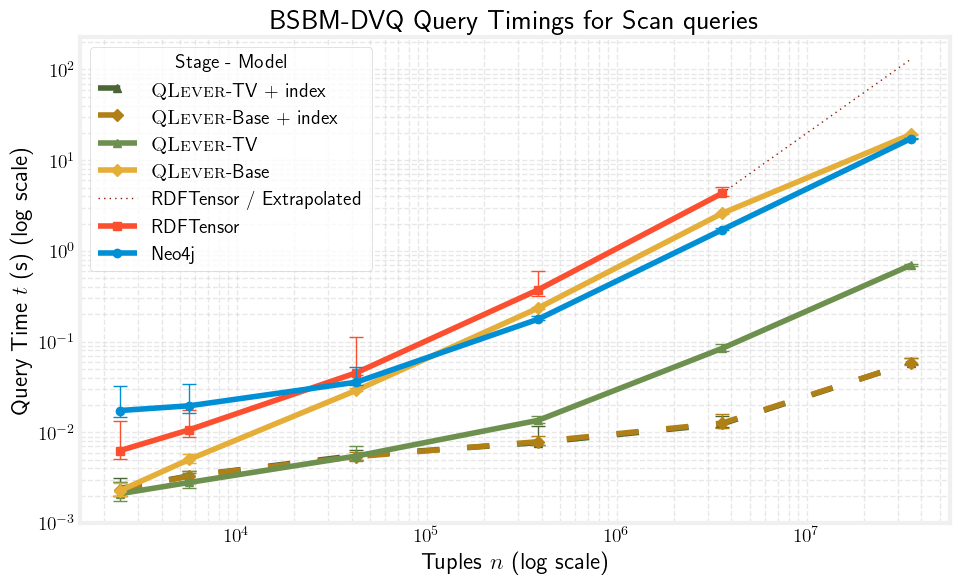

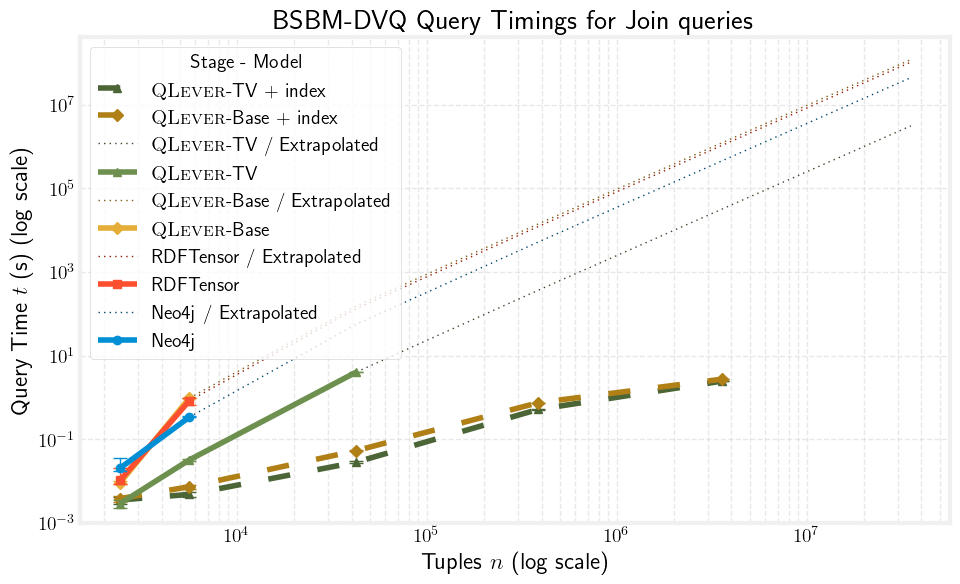

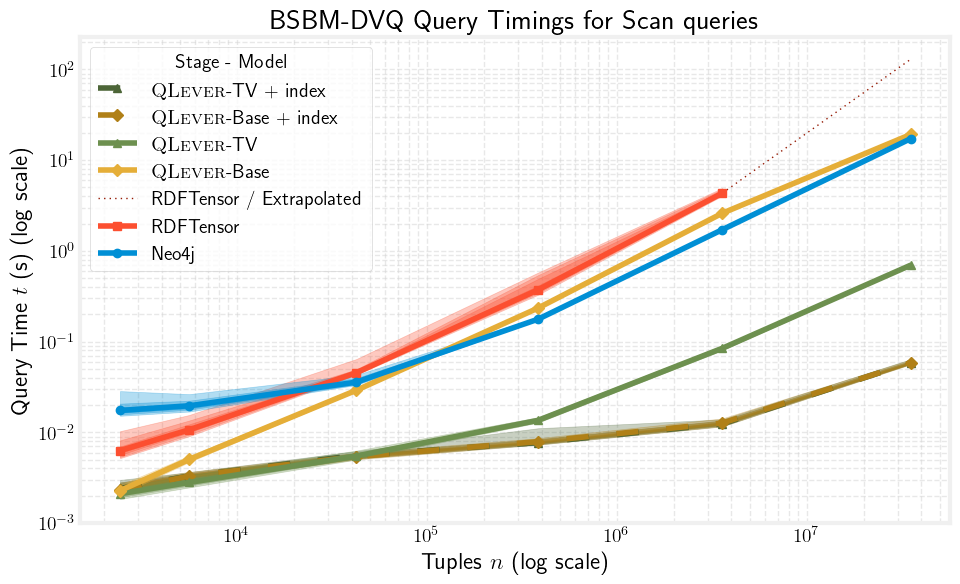

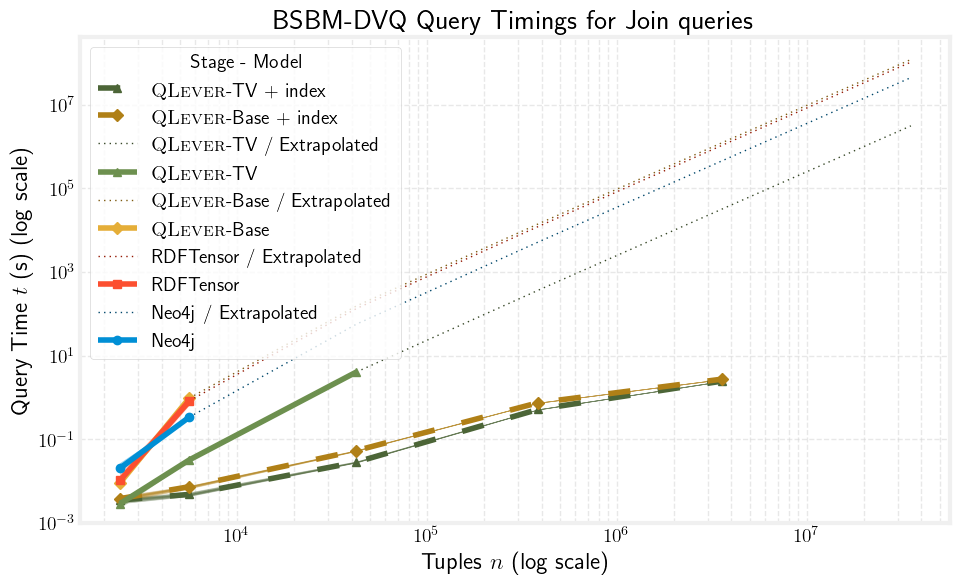

In [104]:
from numpy.polynomial import Polynomial, Hermite, Chebyshev
from utils.format import type_map

def extrapolate_missing_sizes(
    df,
    possible_sizes,
    relevant_measure,
    fns=[
        lambda x: x**2,
        lambda x: x,
        lambda x: np.sqrt(x),
        lambda x: np.ones_like(x),
    ],
):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]

    missing_sizes = [s for s in possible_sizes if s not in df_filtered["size"].unique()]
    missing_sizes.sort()
    # missing_sizes = missing_sizes[:-1]
    missing_sizes = np.array(missing_sizes)
    if df_filtered.empty or len(missing_sizes) == 0:
        return None
    x_data = df_filtered["size"].values
    y_data = df_filtered[relevant_measure].values

    poly = Polynomial.fit(x_data, y_data, deg=2)
    y_pred = poly(missing_sizes)
    # if (y_pred <= 0).any():
    # Phi = np.column_stack([fn(x_data) for fn in fns])
    # # calculate the coefficients using least squares with regularization to prevent overfitting
    # lbd = 0.0
    # coefs = (
    #     np.linalg.inv(Phi.T @ Phi / x_data.shape[0] + lbd * np.eye(Phi.shape[1]))
    #     @ Phi.T
    #     @ y_data
    # )
    # print("Coefficients for extrapolation:", coefs)
    # y_pred = np.dot(coefs, [fn(missing_sizes) for fn in fns])
    extrapolated_df = pd.DataFrame(
        {
            "size": missing_sizes,
            relevant_measure: y_pred,
        }
    )
    if extrapolated_df.empty:
        return None
    # add last known size and measure to the extrapolated df to make the plot look better
    last_known_size = df_filtered["size"].max()
    last_known_measure = df_filtered[df_filtered["size"] == last_known_size][
        relevant_measure
    ].values[0]
    extrapolated_df = pd.concat(
        [
            pd.DataFrame(
                {"size": [last_known_size], relevant_measure: [last_known_measure]}
            ),
            extrapolated_df,
        ],
        ignore_index=True,
    )
    return extrapolated_df


def fit_to_fn(df, relevant_measure, fn: (lambda x: x)):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]
    if df_filtered.empty:
        return None
    x_data = df_filtered["size"].values
    # y_data = df_filtered[relevant_measure].values
    const = x_data[0] if x_data[0] > 0 else 1
    x_data_fn = fn(x_data / const) * const
    Phi = np.vstack([x_data_fn, np.ones(len(x_data_fn))])
    coeffs = np.linalg.lstsq(Phi, df_filtered[relevant_measure].values, rcond=None)[0]
    a, b = coeffs
    y_fitted = a * x_data_fn + b
    fitted_df = pd.DataFrame(
        {
            "size": x_data,
            relevant_measure: y_fitted,
        }
    )
    return fitted_df


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(
    ax,
    df,
    engine,
    difficulty,
    relevant_measure="elapsed_time",
    extrapolate=True,
    fill_pdf=True,
    pdf_steps=5,
    fit_fn=None,
):
    groupings: pd.Series = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = (
        [0.05, 0.5, 0.95]
        if not fill_pdf
        else np.linspace(0, 1, 1 + pdf_steps * 2).tolist()
    )
    print("Quantiles", quantiles)
    mean_timings = groupings.mean().reset_index()
    std_timings = groupings.std().reset_index()
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    possible_sizes = sorted(df["size"].unique())
    all_extended_dfs = []
    for query_type in [QUERY_TYPE.INDEX, QUERY_TYPE.EMBEDDED]:
        for engine in engines[::-1]:
            engine_mean = mean_timings[
                (mean_timings["query_type"] == type_map[query_type.value])
                & (mean_timings["difficulty"] == difficulty)
                & (mean_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == type_map[query_type.value])
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            engine_median = median_timings[
                (median_timings["query_type"] == type_map[query_type.value])
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_std = std_timings[
                (std_timings["query_type"] == type_map[query_type.value])
                & (std_timings["difficulty"] == difficulty)
                & (std_timings["engine"] == engine)
            ]
            if engine_mean.empty or engine_quantiles.empty:
                continue

            extrapolated_df = None
            engine_median = engine_median[engine_median[relevant_measure].notna()]
            engine_quantiles = engine_quantiles[engine_median[relevant_measure].notna()]
            engine_std = engine_std[engine_median[relevant_measure].notna()]
            engine_mean = engine_mean[engine_median[relevant_measure].notna()]
            # extrapolate missing sizes by linear regression

            if extrapolate:
                extrapolated_df = extrapolate_missing_sizes(
                    engine_median, possible_sizes, relevant_measure
                )

            # index are dashed, embedded are solid
            linestyle = (0, (4, 5)) if query_type == QUERY_TYPE.INDEX else "-"
            color = colors[engine]
            if query_type == QUERY_TYPE.INDEX:
                color = adjust_lightness(color, 0.7)
            symbol = symbols[engine]
            lbl = f"{engine}"
            if query_type.value != QUERY_TYPE.EMBEDDED.value:
                lbl += f" + {query_type.value}"
            # lbl += " $t$"
            if (
                extrapolated_df is not None
                and not extrapolated_df.empty
                and extrapolated_df.shape
                and (extrapolated_df[relevant_measure] > 0).all()
            ):
                all_extended_dfs.append(extrapolated_df)
                print(
                    f"Extrapolated sizes for {engine} - {query_type.value}: {extrapolated_df['size'].tolist()}",
                    extrapolated_df[relevant_measure].tolist(),
                    "existing points",
                    engine_median["size"].tolist(),
                    engine_median[relevant_measure].tolist(),
                )
                ax.plot(
                    extrapolated_df["size"],
                    extrapolated_df[relevant_measure],
                    linestyle=(0, (1, 3)),
                    label=f"{lbl} / Extrapolated",
                    color=adjust_lightness(color, 0.5),
                    linewidth=1,
                )
            if fit_fn is not None and fit_fn is not False:
                fit_fn = (
                    fit_fn if isinstance(fit_fn, type(lambda: None)) else lambda x: x
                )
                fitted_df = fit_to_fn(
                    engine_median,
                    relevant_measure,
                    fn=fit_fn,
                )
                if fitted_df is not None and not fitted_df.empty:
                    ax.plot(
                        fitted_df["size"],
                        fitted_df[relevant_measure],
                        linestyle=(0, (5, 10)),
                        label=f"{lbl} / Fit",
                        color=adjust_lightness(color, 0.8),
                        linewidth=1,
                    )
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                symbol,
                linestyle=linestyle,
                label=lbl,
                color=color,
                linewidth=4,
            )
            if fill_pdf:
                if engine_median["size"].shape[0] > 1:
                    for i in range(0, pdf_steps - 1):
                        ax.fill_between(
                            engine_quantiles["size"],
                            engine_quantiles[quantiles[pdf_steps - 1 - i]],
                            engine_quantiles[quantiles[pdf_steps + 1 + i]],
                            color=color,
                            alpha=0.3,
                        )
            else:
                upper_std = engine_quantiles[0.95] - engine_median[relevant_measure]
                lower_std = engine_median[relevant_measure] - engine_quantiles[0.05]
                # lower_std[engine_median[relevant_measure] - lower_std <= 0] = np.abs(
                #     engine_median[relevant_measure] - 1e-12
                # )
                # if "time" in relevant_measure:
                #     lower_std[lower_std <= 0] = 1e-2
                ax.errorbar(
                    engine_median["size"],
                    engine_median[relevant_measure],
                    yerr=[
                        lower_std,
                        upper_std,
                    ],
                    barsabove=True,
                    capsize=5,
                    linewidth=1,
                    fmt="none",
                    # label=f"5\%-95\% quantiles ({engine})",
                    color=color,
                )
    return pd.concat(all_extended_dfs) if all_extended_dfs else None


overview_dir = figures_dir / "overview"
overview_dir.mkdir(exist_ok=True, parents=True)


def calc_extra_ticks(series: pd.Series, tweens=[2, 3, 4, 5, 6, 7, 8, 9]):
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    min_size = int(np.log10(series.min())) - 1
    max_size = int(np.log10(series.max())) + 2

    extra_ticks = [10**i * tween for i in range(min_size, max_size) for tween in tweens]
    return extra_ticks


extra_y_ticks = calc_extra_ticks(timings_df["elapsed_time"])
extra_x_ticks = calc_extra_ticks(timings_df["size"])
for fill_pdf in [False, True]:
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # ax = axes[i] if len(difficulties) > 1 else axes
        # set the suxbtitle to the difficulty

        extended_dfs = plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            fill_pdf=fill_pdf,
            fit_fn=False,
            extrapolate=True,
        )
        complete_plotted_df = (
            pd.concat([timings_df, extended_dfs])
            if extended_dfs is not None
            else timings_df
        )
        extra_y_ticks_plt = calc_extra_ticks(complete_plotted_df["elapsed_time"])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Tuples $n$ (log scale)")
        ax.set_ylabel("Query Time $t$ (s) (log scale)")
        ax.set_title(f"{modes.get(mode, mode)} Query Timings for {difficulty} queries")
        ax.set_ylim(bottom=1e-3)
        ax.legend()
        ax.grid(True, which="both", ls="--", color="lightgray", alpha=0.5)
        fill_str = "_filled" if fill_pdf else ""
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}{fill_str}.tex",
            extra_tikzpicture_parameters=[
                f"scale={plot_scale}",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=2, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="0.6\\linewidth",
            axis_width="1\\linewidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}_legend{fill_str}.tex",
            extra_tikzpicture_parameters=[
                f"scale={plot_scale}",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=5, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="1.8\\linewidth",
            axis_width="2.2\\linewidth",
        )
        # plt.savefig(overview_dir / f"{mode}_timings_{difficulty}{fill_str}.png")
        # plt.show()

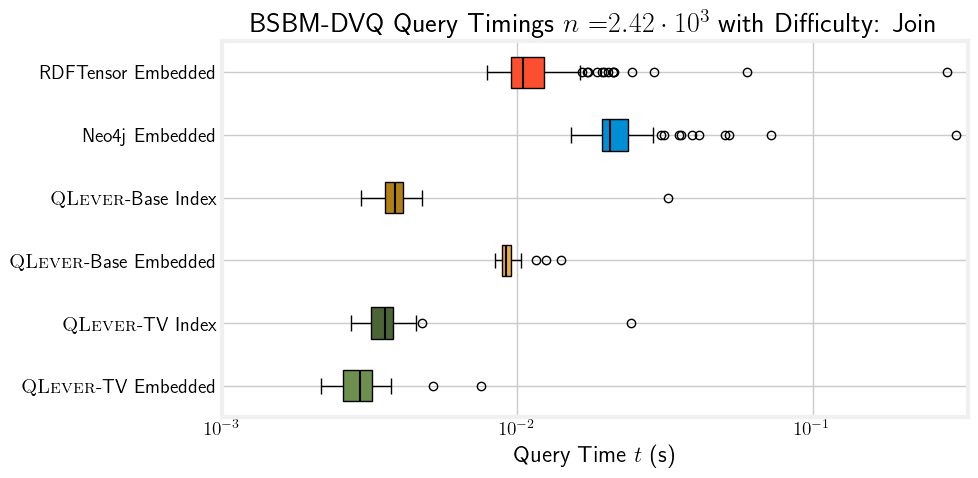

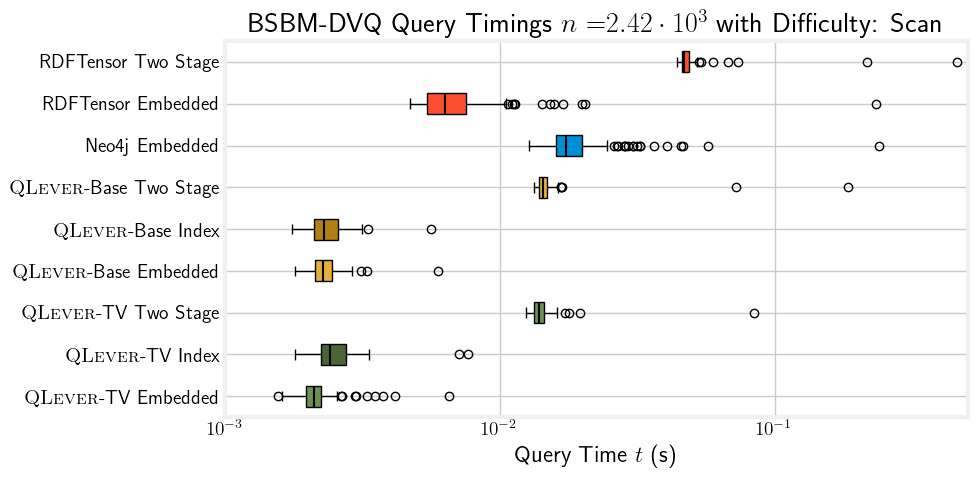

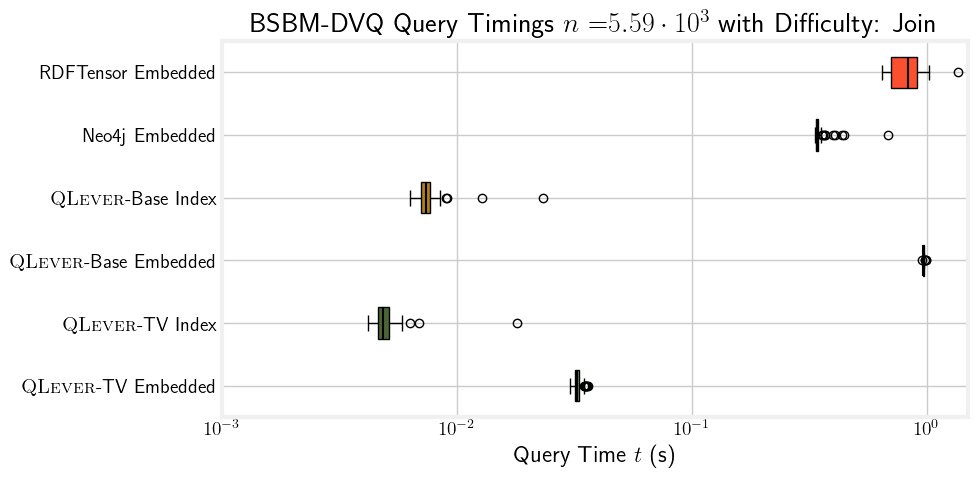

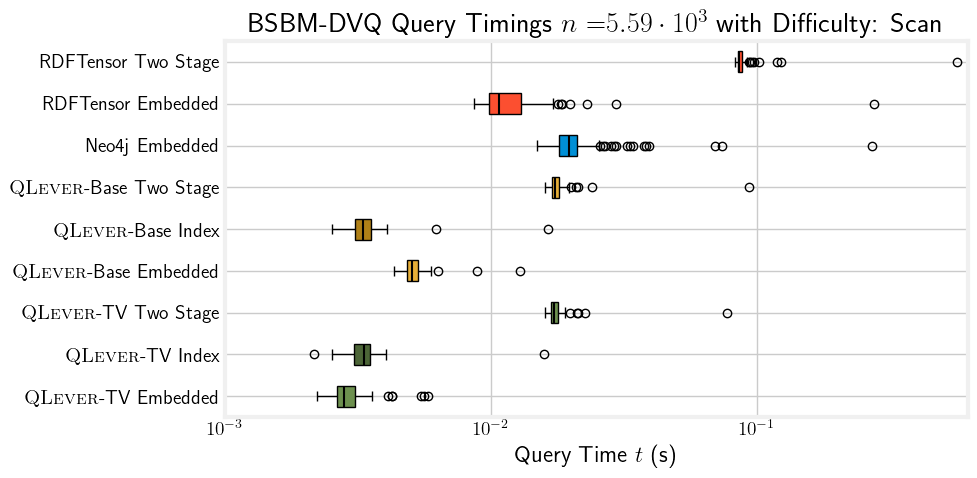

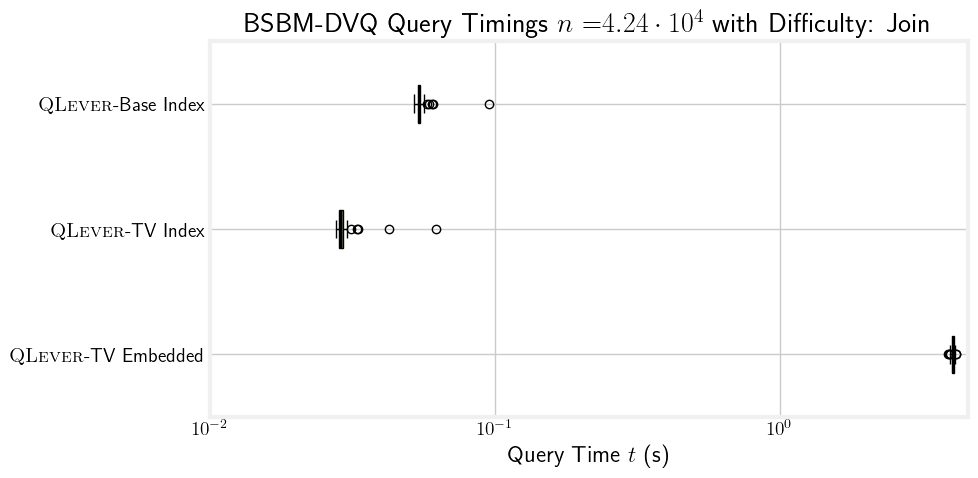

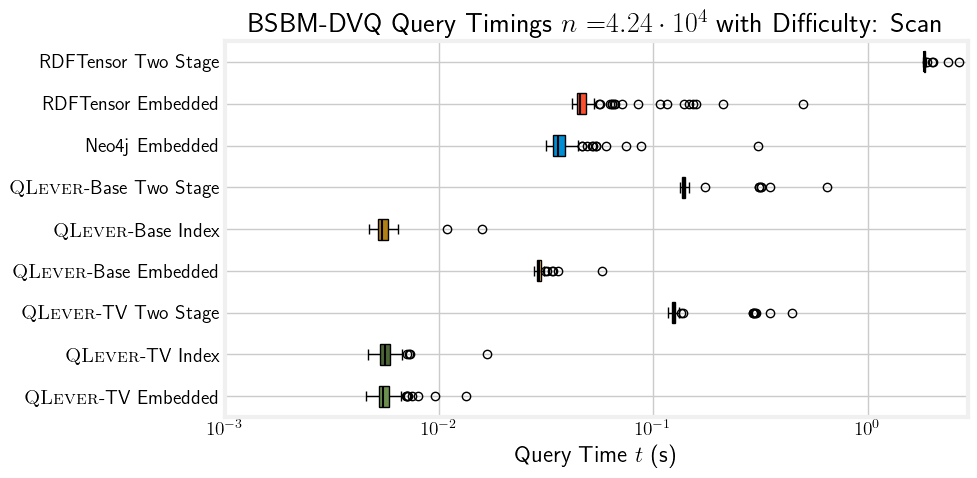

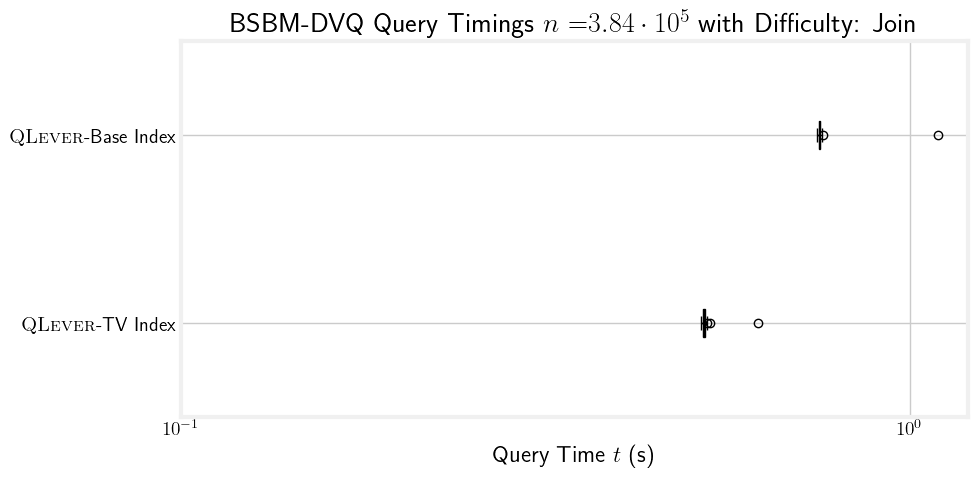

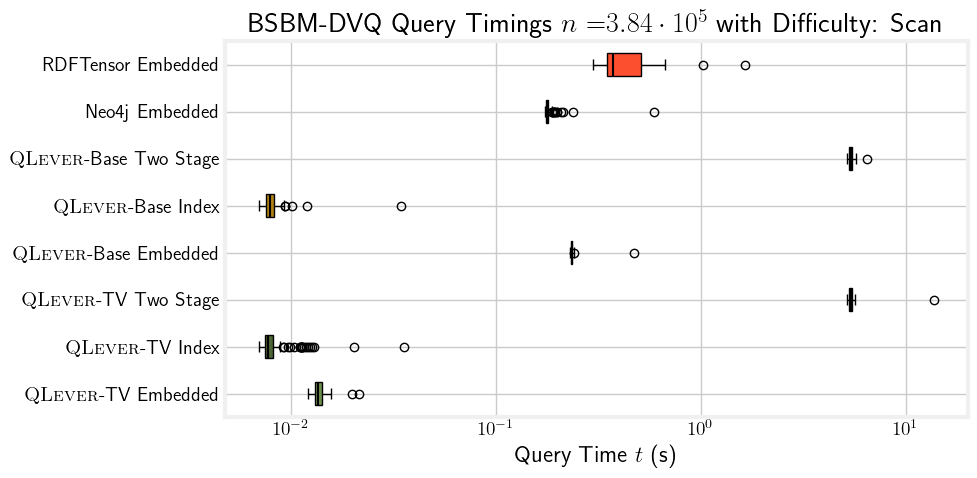

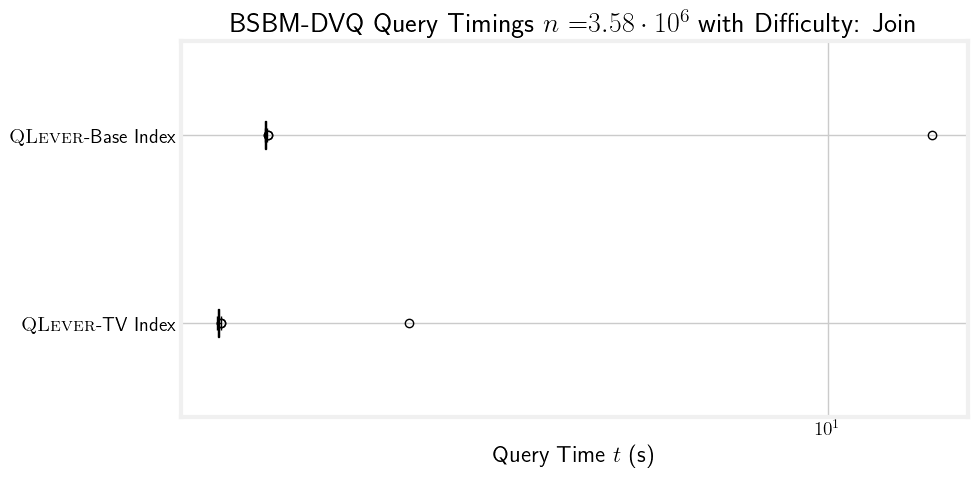

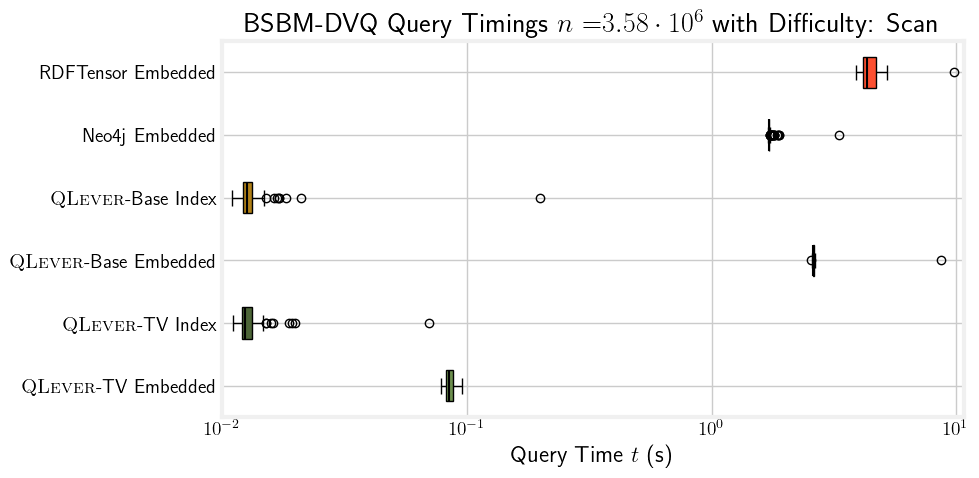

No measures for size 35177974 and difficulty Join


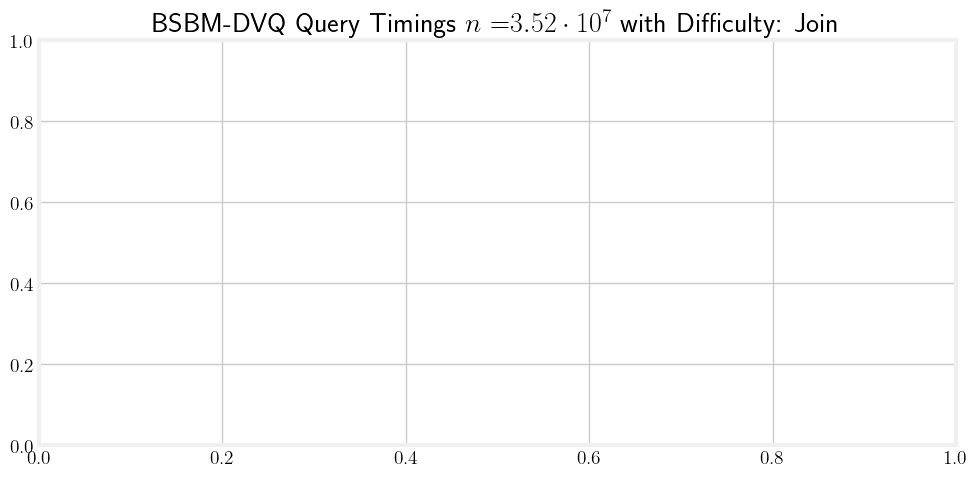

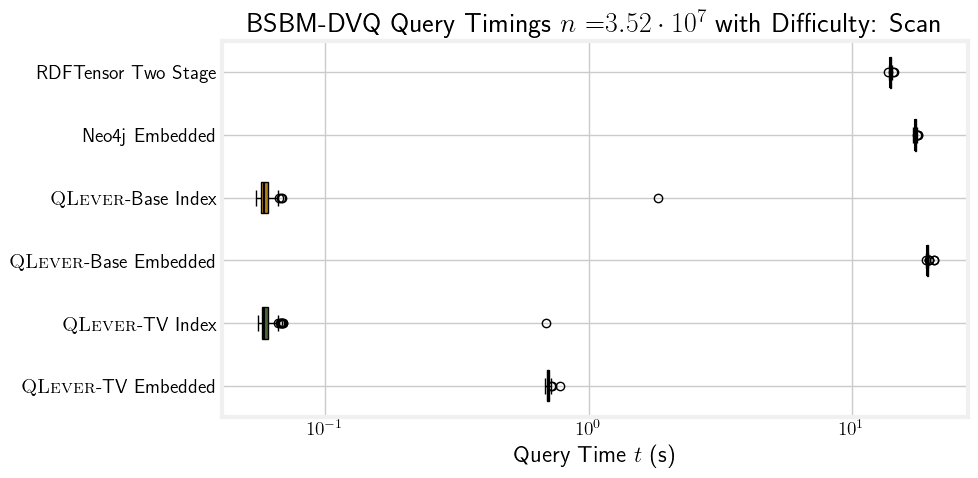

In [105]:
def plot_boxplot(
    ax: plt.Axes,
    df: pd.DataFrame,
    size: int,
    difficulty: str,
    relevant_measure: str = "elapsed_time",
):
    ax.set_title(
        f" {modes[mode]} Query Timings $n=${to_pow_10(size)} with Difficulty: {difficulty}"
    )
    size_df = df[df["size"] == size]
    engine_types = size_df.apply(
        lambda row: (row["engine"], row["query_type"]), axis=1
    ).unique()

    tick_labels = list(engine_types)
    measures: list[pd.Series] = [
        size_df[
            (size_df["difficulty"] == difficulty)
            & (size_df["engine"] == engine)
            & (size_df["query_type"] == query_type)
        ][relevant_measure]
        for engine, query_type in tick_labels
    ]
    # filter infinite and nan values from measures and corresponding tick labels
    measures_f = [
        measures[i].replace([np.inf, -np.inf], np.nan).dropna()
        for i in range(len(measures))
    ]
    measures = [
        measures_f[i] for i in range(len(measures_f)) if not measures_f[i].shape[0] == 0
    ]
    tick_labels = [
        tick_labels[i]
        for i in range(len(tick_labels))
        if not measures_f[i].shape[0] == 0
    ]
    if len(measures) == 0:
        print(f"No measures for size {size} and difficulty {difficulty}")
        return
    all_measures = pd.concat(measures)
    bplot = ax.boxplot(
        measures,
        tick_labels=[f"{engine} {query_type}" for engine, query_type in tick_labels],
        vert=False,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
        # showfliers=False,
    )
    ax.set_xlabel("Query Time $t$ (s)")
    ax.set_xscale("log")
    ax.set_xticklabels([], minor=True)
    # fill with colors
    for patch, (engine, query_type) in zip(bplot["boxes"], tick_labels):
        color = colors[engine]
        if query_type == "Index":
            color = adjust_lightness(color, 0.7)
        patch.set_facecolor(
            adjust_lightness(color)
            if query_type == QUERY_TYPE.INDEX.value
            else color
        )
    if abs(all_measures.min() - all_measures.max()) < 10:
        min_power = int(np.floor(np.log10(all_measures.min())))
        max_power = int(np.ceil(np.log10(all_measures.max())))
        ax.set_xlim(left=10**min_power, right=all_measures.max()*1.1)


boxplots_dir = figures_dir / "boxplots"
boxplots_dir.mkdir(exist_ok=True, parents=True)
for est_size in timings_df["estimated_size"].unique():
    for difficulty in difficulties[::-1]:
        fig, ax = plt.subplots(1, figsize=(10, 5))
        eval_size = timings_df[timings_df["estimated_size"] == est_size][
            "size"
        ].unique()[0]
        plot_boxplot(ax, timings_df, eval_size, difficulty)
        plt.tight_layout()
        tikzplotlib.save(
            boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                f"scale={plot_scale}",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=2, 
                    extra x ticks={"""
                + ",".join(map(str, extra_y_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.2\\linewidth",
            axis_width="1.5\\linewidth",
        )
        plt.savefig(boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.png")
        plt.show()

In [106]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-09-03 12:10:28.675017,0.0,69525504,-1,-1,2,2418,3,Scan,Embedded,1,\systemname-TV
1,2026-09-03 12:10:28.691577,0.0,69689344,-1,-1,2,2418,3,Scan,Embedded,1,\systemname-TV
2,2026-09-03 12:10:28.817383,0.0,77717504,-1,-1,2,2418,3,Scan,Embedded,1,\systemname-TV
3,2026-09-03 12:10:28.946809,0.0,77705216,-1,-1,2,2418,3,Scan,Embedded,1,\systemname-TV
4,2026-09-03 12:10:29.066173,0.0,77705216,-1,-1,2,2418,3,Scan,Embedded,1,\systemname-TV
...,...,...,...,...,...,...,...,...,...,...,...,...
109408,2026-09-03 16:19:00.270476,0.0,754675712,-1,-1,2,35177974,7,Join,Two Stage,100000,RDFTensor
109409,2026-09-03 16:19:01.670383,0.0,754675712,-1,-1,2,35177974,7,Join,Two Stage,100000,RDFTensor
109410,2026-09-03 16:19:01.945003,0.0,754675712,-1,-1,2,35177974,7,Join,Two Stage,100000,RDFTensor
109411,2026-09-03 16:19:02.201436,0.0,754675712,-1,-1,2,35177974,7,Join,Two Stage,100000,RDFTensor


In [107]:
stats_df_only_valid["cpu_percent"] = stats_df_only_valid["cpu_percent"].astype(float)
stats_df_only_valid["mem_usage_mb"] = stats_df_only_valid["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

Quantiles [0.05, 0.5, 0.95]


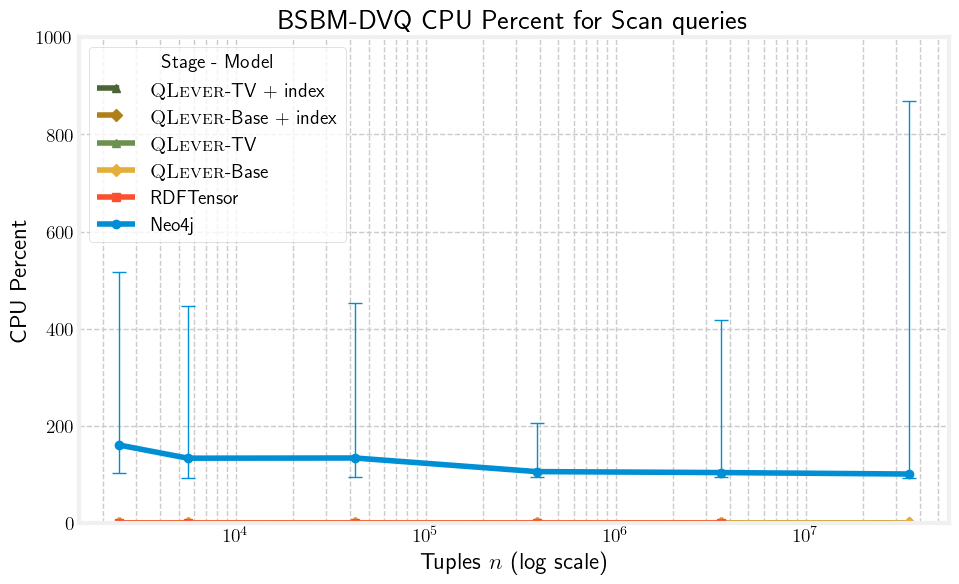

Quantiles [0.05, 0.5, 0.95]


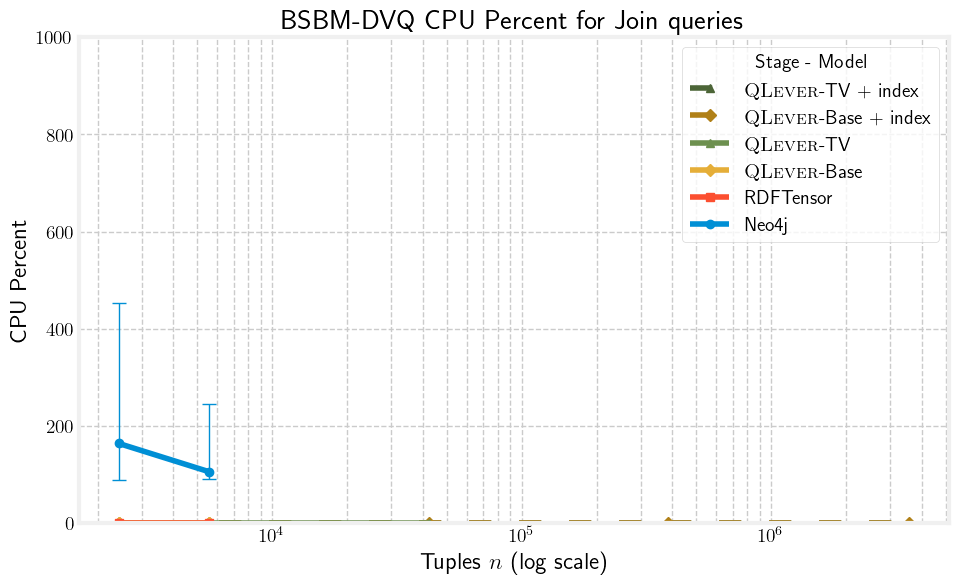

Quantiles [0.05, 0.5, 0.95]


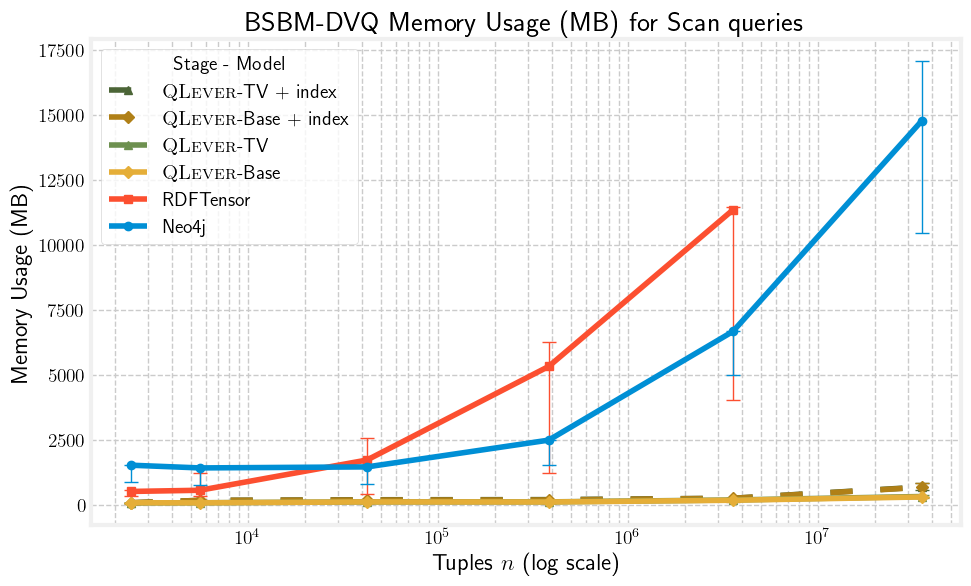

Quantiles [0.05, 0.5, 0.95]


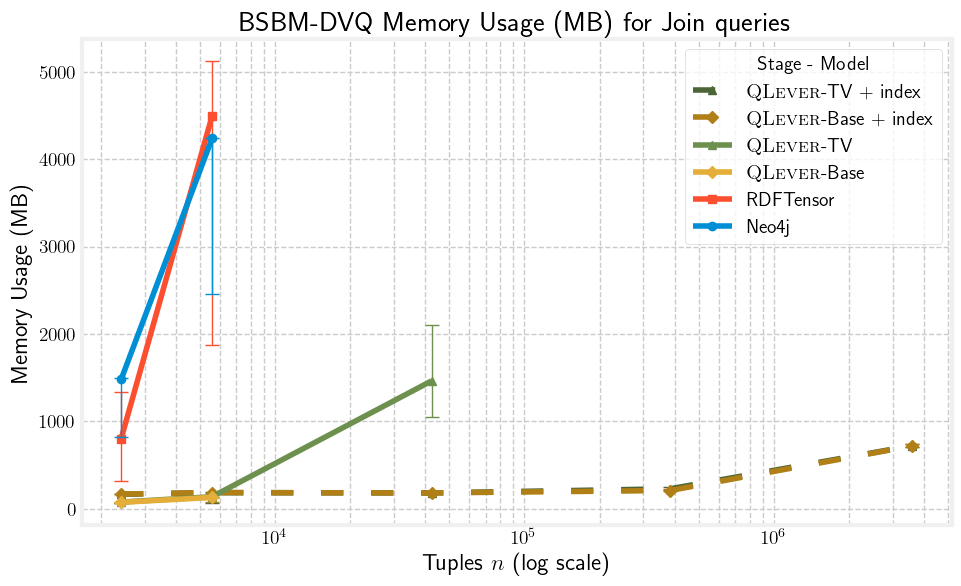

In [108]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_stats_map = {
    "cpu_percent": "CPU Percent",
    "mem_usage_mb": "Memory Usage (MB)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_stats_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            stats_df_only_valid,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=False,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Tuples $n$ (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for {difficulty} queries")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        if relevant_measure == "cpu_percent":
            ax.set_ylim(0, 1000)
            ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                f"scale={plot_scale}",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="0.6\\linewidth",
            axis_width="1\\linewidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                f"scale={plot_scale}",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.8\\linewidth",
            axis_width="2.2\\linewidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()


Quantiles [0.05, 0.5, 0.95]


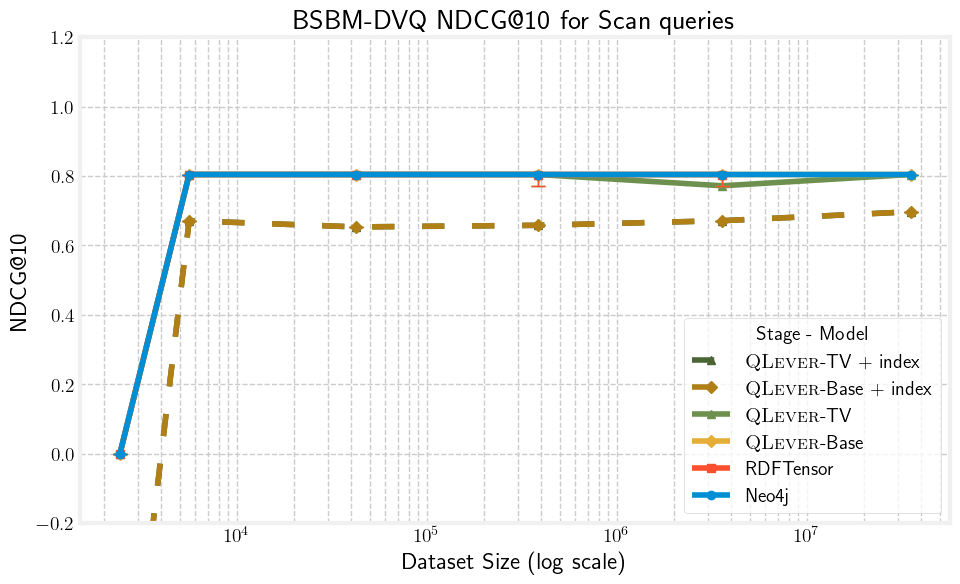

Quantiles [0.05, 0.5, 0.95]


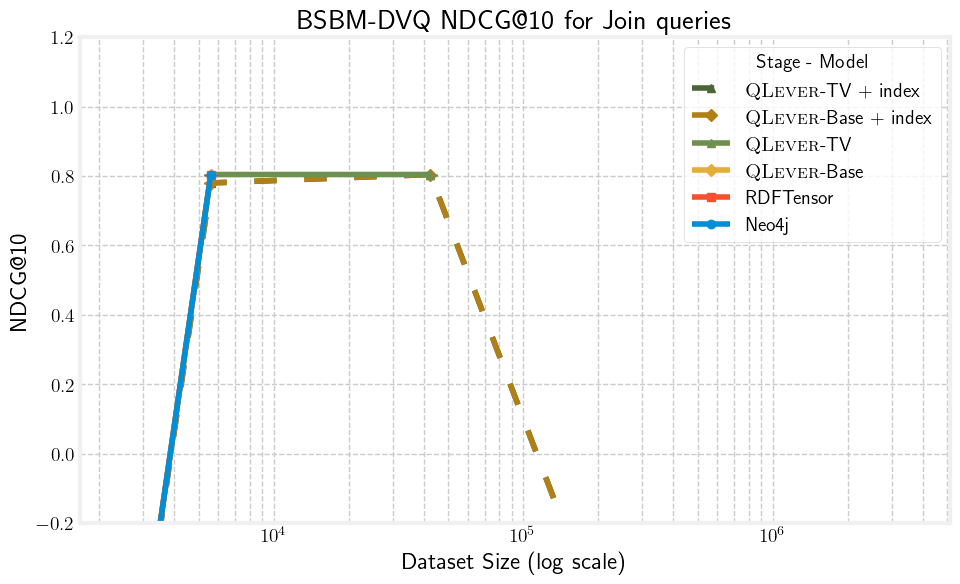

Quantiles [0.05, 0.5, 0.95]


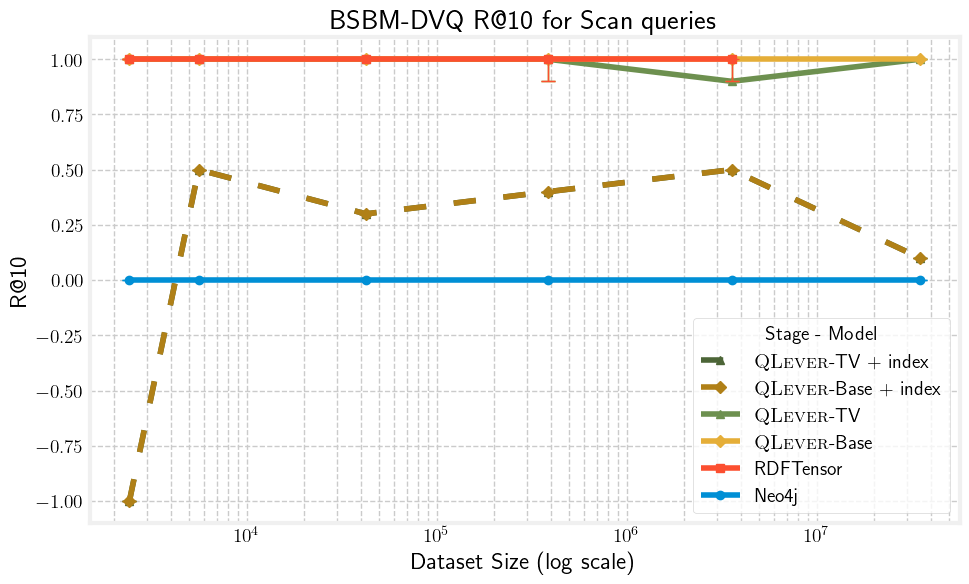

Quantiles [0.05, 0.5, 0.95]


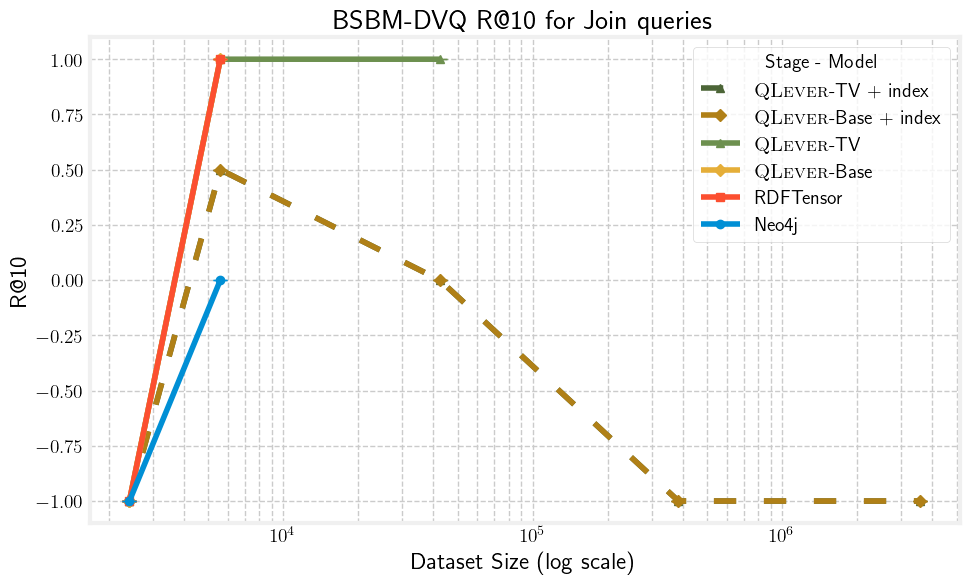

Quantiles [0.05, 0.5, 0.95]


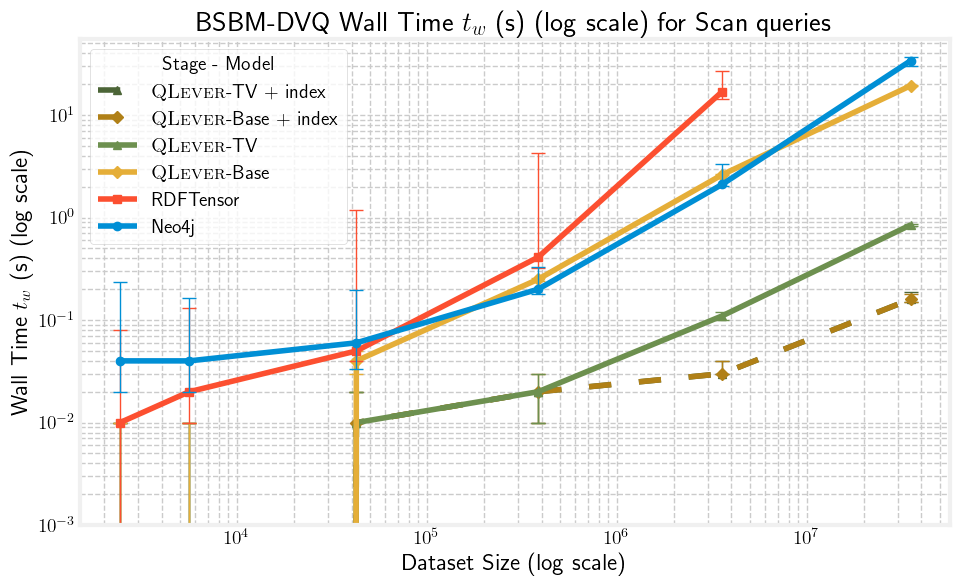

Quantiles [0.05, 0.5, 0.95]


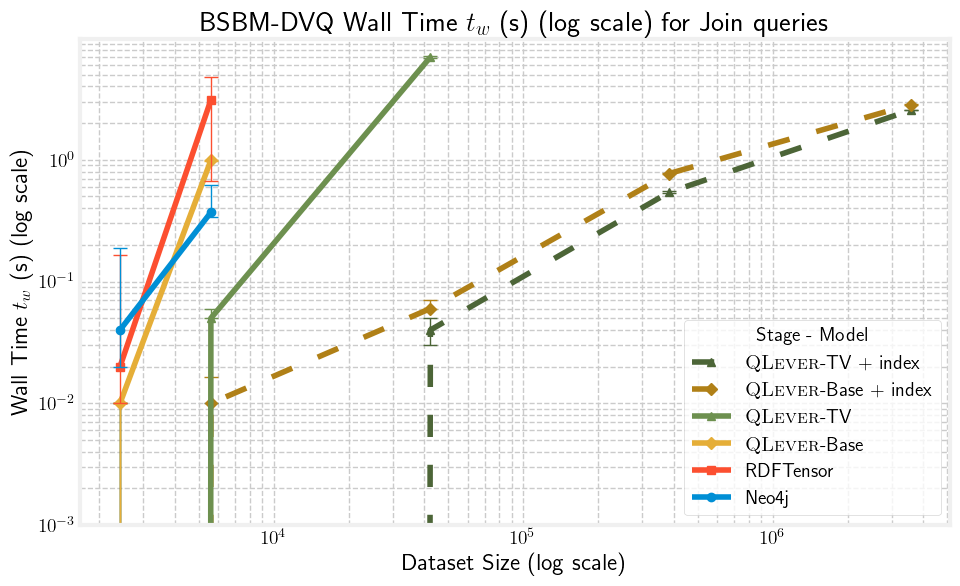

In [109]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_measure_map = {
    "ndcg_score": "NDCG@10",
    "recall_score": "R@10",
    "wall_time": "Wall Time $t_w$ (s) (log scale)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_measure_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=False,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Dataset Size (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for {difficulty} queries")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        if relevant_measure == "wall_time":
            ax.set_yscale("log")
            ax.set_ylim(bottom=1e-3)
        elif relevant_measure == "ndcg_score":
            ax.set_ylim(-0.2, 1.2)
        ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                f"scale={plot_scale}",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.8\\linewidth",
            axis_width="2.2\\linewidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                f"scale={plot_scale}",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.8\\linewidth",
            axis_width="2.2\\linewidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()


In [110]:
index_test_dir = results_dir / mode / "index_tests"
index_test_timing_file = index_test_dir / "index_query_timings.csv"
if index_test_timing_file.exists():
    index_test_timings_df = pd.read_csv(index_test_timing_file)
else:
    index_test_timings_df = pd.DataFrame()
index_test_timings_df

,mode,run,time,searchK,ndcg_score,recall_score
0,hnsw,0,0.044786,1,0.685134,0.125
1,hnsw,1,0.041288,1,0.807537,0.000
2,hnsw,2,0.050779,1,0.661515,0.250
3,hnsw,3,0.042582,1,0.807537,0.000
4,hnsw,4,0.039520,1,0.807537,0.000
...,...,...,...,...,...,...
4603,ivf,251,0.056236,16,0.807537,1.000
4604,ivf,252,0.047871,16,0.807537,1.000
4605,ivf,253,0.045971,16,0.807537,1.000
4606,ivf,254,0.053712,16,0.807537,1.000


  searchK recall_score                time          
                  0.25      0.75      0.25      0.75
0       1       0.0000  0.187500  0.039404  0.043746
1       4       0.1250  0.328125  0.038545  0.044795
2       8       0.2500  0.500000  0.041386  0.048279
3      12       0.3750  0.625000  0.040810  0.048812
4      16       0.4375  0.687500  0.039768  0.047302
5      20       0.5000  0.687500  0.039760  0.044978
6      24       0.5625  0.750000  0.040030  0.047538
7      28       0.5625  0.765625  0.041511  0.048399
8      32       0.6250  0.812500  0.040198  0.047411
  searchK recall_score              time          
                  0.25    0.75      0.25      0.75
0       1     0.125000  0.3125  0.040191  0.046753
1       2     0.250000  0.4375  0.039916  0.045080
2       4     0.437500  0.6875  0.041436  0.048417
3       6     0.609375  0.8125  0.041864  0.047999
4       8     0.687500  0.8750  0.042549  0.052980
5      10     0.812500  0.9375  0.044650  0.050819
6      12

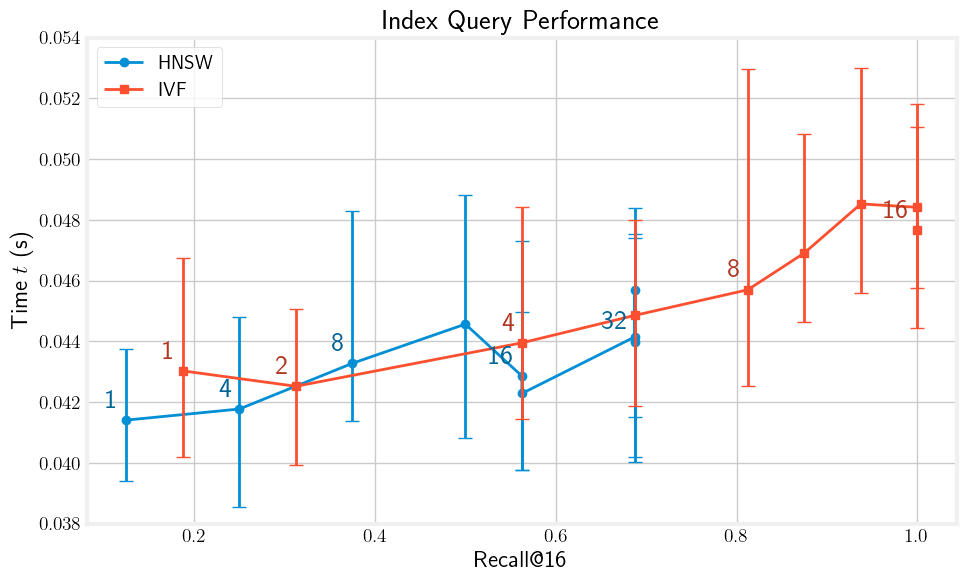

In [111]:
from re import search


mode_names = {"hnsw": "HNSW", "ivf": "IVF"}
mode_colors = {
    mode: color
    for mode, color in zip(mode_names.keys(), ["C0", "C1", "C2", "C3", "C4"])
}


def plot_dual_plot(
    ax: plt.Axes,
    df: pd.DataFrame,
    mode: str,
    relevant_measure_y: str = "time",
    relevant_measure_x: str = "recall_score",
    varying_param: str = "searchK",
    quantiles=[0.25, 0.75],
):
    if df.empty:
        print(f"No data for engine {mode} and difficulty {difficulty}")
        return
    df_filtered = df[
        (df["mode"] == mode)
        & (df[relevant_measure_x].replace([np.inf, -np.inf], np.nan).notna())
        & (df[relevant_measure_y].replace([np.inf, -np.inf], np.nan).notna())
    ]
    if df_filtered.empty:
        print(f"No data for engine {mode} and difficulty {difficulty}")
        return
    df_filtered.sort_values(varying_param, inplace=True)
    search_group = df_filtered.groupby([varying_param])[
        [relevant_measure_x, relevant_measure_y]
    ]
    search_group_mean = search_group.mean().reset_index()
    search_group_median = search_group.median().reset_index()
    search_group_quantiles = search_group.quantile(quantiles).unstack().reset_index()
    search_group_std = search_group.std().reset_index()
    qps = 1 / search_group_mean[relevant_measure_y]
    ax.plot(
        search_group_median[relevant_measure_x],
        search_group_median[relevant_measure_y],
        marker="o" if mode == "hnsw" else "s",
        label=mode_names.get(mode, mode),
        color=mode_colors[mode],
        linewidth=2,
        # linestyle="--",
    )
    print(search_group_quantiles)
    ax.errorbar(
        search_group_median[relevant_measure_x],
        search_group_median[relevant_measure_y],
        yerr=[
            search_group_median[relevant_measure_y]
            - search_group_quantiles[relevant_measure_y, quantiles[0]],
            search_group_quantiles[relevant_measure_y, quantiles[1]]
            - search_group_median[relevant_measure_y],
        ],
        fmt="none",
        ecolor=mode_colors[mode],
        alpha=1,
        capsize=5,
        linewidth=2,
    )
    # add labes for searchK values
    draw_rows = (
        2 ** np.arange(0, np.log2(search_group_median[varying_param].max()) + 1)
    ).tolist()
    for _, row in search_group_median.iterrows():
        if row[varying_param] in draw_rows:
            ax.annotate(
                f"{int(row[varying_param])}",
                xy=(row[relevant_measure_x], row[relevant_measure_y]),
                xytext=(-5, 5),
                textcoords="offset points",
                fontsize=20,
                ha="right",
                va="bottom",
                color=darken_color(mode_colors[mode]),
                # bbox=dict(
                #     facecolor="white",
                #     alpha=0.5,
                #     edgecolor="none",
                #     # width=2,
                #     # height=2,
                # ),
            )


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

plot_dual_plot(
    ax,
    index_test_timings_df,
    mode="hnsw",
)
plot_dual_plot(
    ax,
    index_test_timings_df,
    mode="ivf",
)
ax.set_ylabel("Time $t$ (s)")
ax.set_xlabel("Recall@16")
ax.set_title("Index Query Performance")
ax.legend()
ax.set_ylim([0.038, 0.054])

tikzplotlib.save(
    stat_dir / f"{mode}_index_query_performance.tex",
    extra_tikzpicture_parameters=[
        f"scale={plot_scale}",
        """every axis/.style={
            legend pos=south west, 
            legend style={
        font=\\small},
            legend columns=1, 
        }""",
    ],
    axis_height="0.6\\linewidth",
    axis_width="1\\linewidth",
)